In [1]:
import argparse
import datetime
import math
import os
from time import time
from typing import Any, List, Tuple

import numpy as np
import pandas as pd
import torch
from joblib import Parallel, delayed

from artifacts import (
    build_plot_df_wrapper,
    save_csv_artifact,
    save_plot_strategy,
)
from BoTorchOptimizer import BoTorchOptimizer
from data import (
    apply_final_treatment,
    join_metadata,
    load_metadata_artefacts,
    load_odds,
)
from dependencies.config import load_config
from dependencies.utils import get_bet_return, softmax, save_df_as_parquet
from filter import filter_by_linear_combination
from GameProbs import GameProbs


config = load_config("config/config.yml")



metadata, gameid_to_outcome = load_metadata_artefacts(config.metadata_path)
odds = load_odds(config.odds_path)
print(odds.shape)
odds = join_metadata(odds, metadata)

odds = odds.sort_values(["Datetime", "GameId"], ascending=True)


/Users/marcosbarbosa/anaconda3/envs/soccer_betting_strategy_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(2113785, 7)


In [2]:
config.odds_path

'data/odds-new.parquet'

In [3]:
from dependencies.utils import read_all_parquet

In [4]:
odds['year_month'] = odds.Datetime.apply(lambda x: x.strftime('%Y-%m'))

In [5]:
df_plot =  odds.groupby('year_month')['Sportsbook'].nunique().reset_index()
df_plot = df_plot.rename(columns={'Sportsbook':'n_sportsbooks'})

In [7]:
odds[odds.year_month >= "2023-01"].Sportsbook.nunique()

51

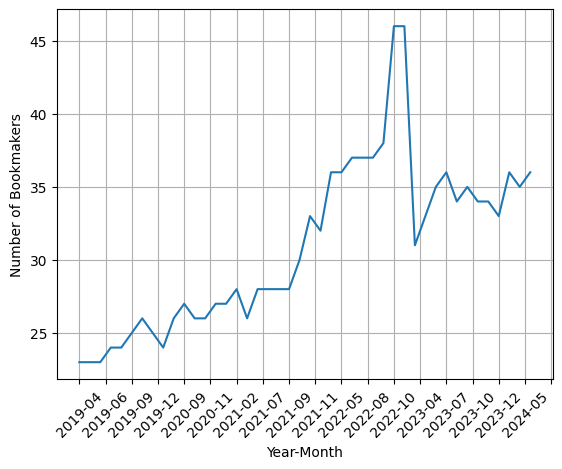

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have a DataFrame named df_plot with columns 'year_month' and 'n_sportsbooks'
sns.lineplot(data=df_plot, x='year_month', y='n_sportsbooks')
plt.xlabel('Year-Month')
plt.ylabel('Number of Bookmakers')

# Adjust x ticks more sparsely
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))
plt.grid(True)
plt.show()


In [12]:
#df_eda = read_all_parquet('artefacts/botorch_aggregatorDatetime_min_games1_bookmakersNone_do_baselineFalse_20240427114602/EDA')
df_eda = read_all_parquet('artefacts/20240506155232/EDA')
df_eda.shape

(6765, 18)

In [86]:
df_eda['year'] = df_eda.Datetime.apply(lambda x: str(x)[0:4])
df_eda['year_month'] = df_eda.Datetime.apply(lambda x: x.strftime('%Y-%m'))
df_eda['Datetime'] = df_eda.Datetime.apply(str)

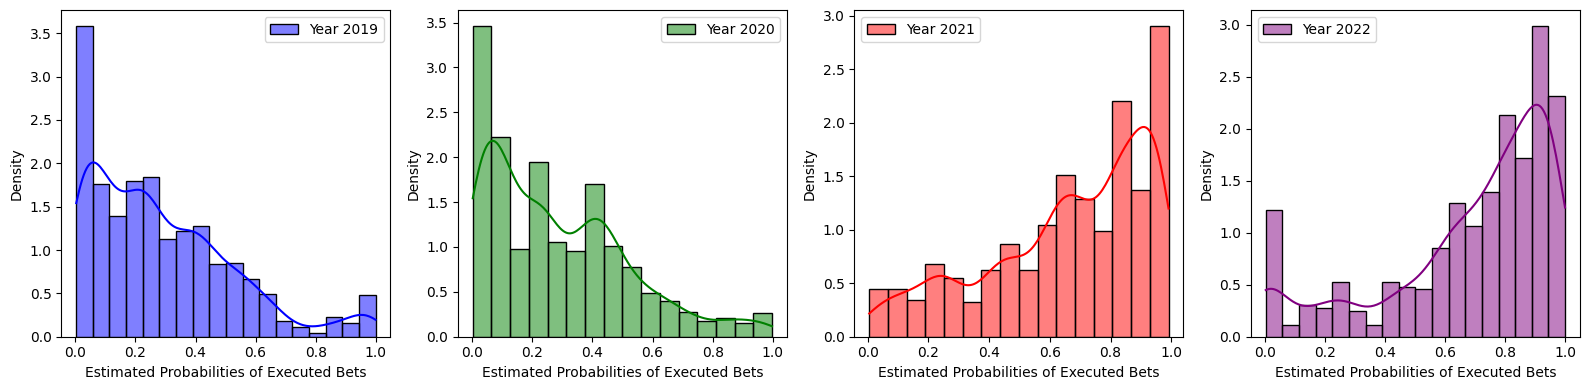

In [88]:
import seaborn as sns

df = df_eda.copy()

# Unique categories and their assigned colors
categories = df['year'].unique()
categories = sorted(categories)
colors = ['blue', 'green', 'red', 'purple']  # Distinct colors for each category

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 4))

# Flatten the array of axes for easier iteration
axes = axes.flatten()

# Loop through the categories and corresponding axes
for ax, category, color in zip(axes, categories, colors):
    # Subset to the category
    subset = df[df['year'] == category]
    
    # Plot the density histogram for each category
    sns.histplot(subset['real_prob'], kde=True, stat='density', label=f'Year {category}', ax=ax, color=color)
    
    # Set titles and labels
    ax.set_xlabel('Estimated Probabilities of Executed Bets')
    ax.set_ylabel('Density')
    ax.legend()  # Show the legend

# Adjust layout to prevent overlap and make all subplots square
fig.tight_layout()

# Show the plot
plt.show()

In [89]:
import pandas as pd

def multi_column_value_counts(df, columns):
    """
    Computes normalized value counts for multiple categorical columns.

    Args:
    df (pandas.DataFrame): The DataFrame containing the data.
    columns (list of str): The list of columns for which to compute the value counts.

    Returns:
    pandas.Series: A Series containing the normalized counts for each unique combination of values in the specified columns.
    """
    # Group by the specified columns and count occurrences
    counts = df.groupby(columns).size()

    # Normalize the counts to get percentages
    normalized_counts = counts / counts.groupby(level=0).transform('sum')

    return normalized_counts


In [90]:
df1 = multi_column_value_counts(df_eda, ['year_month', 'Market']).reset_index().rename(columns={0: 'percentage'}).sort_values(by=['year_month', 'percentage'], ascending=[True, False])
df1

,year_month,Market,percentage
3,2019-04,over/under,0.489796
4,2019-04,spread,0.224490
0,2019-04,both_score,0.102041
1,2019-04,exact,0.102041
2,2019-04,h2h,0.081633
...,...,...,...
128,2022-10,both_score,0.022642
135,2022-11,spread,0.549708
134,2022-11,over/under,0.380117
132,2022-11,both_score,0.040936


In [91]:
# Pivot the DataFrame to get years as the x-axis and each market as a separate column
df_pivoted = df1.pivot(index='year_month', columns='Market', values='percentage')

# Reset index to get 'year' back as a column
df_pivoted.reset_index(inplace=True)

df_pivoted = df_pivoted.fillna(0)

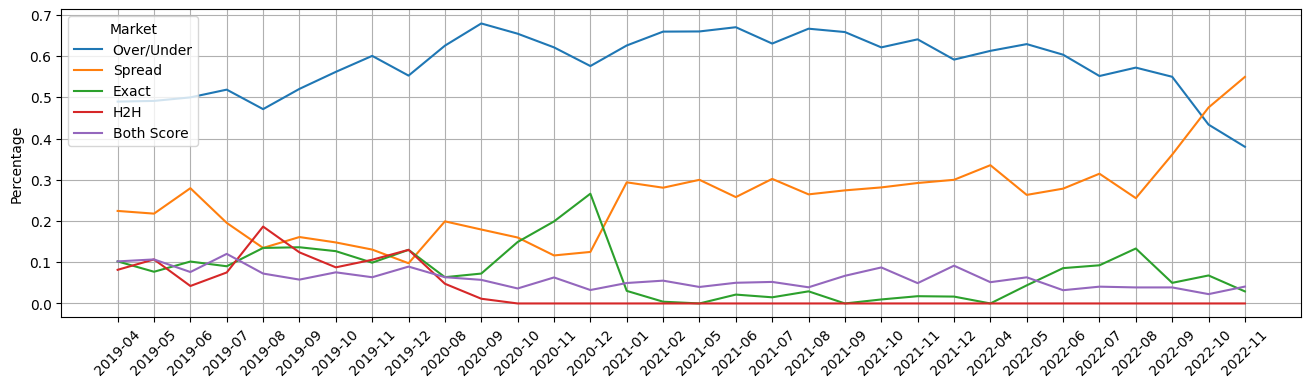

In [92]:
# Plotting
plt.figure(figsize=(16, 4))
sns.lineplot(data=df_pivoted, x='year_month', y='over/under', label='Over/Under')
sns.lineplot(data=df_pivoted, x='year_month', y='spread', label='Spread')
sns.lineplot(data=df_pivoted, x='year_month', y='exact', label='Exact')
sns.lineplot(data=df_pivoted, x='year_month', y='h2h', label='H2H')
sns.lineplot(data=df_pivoted, x='year_month', y='both_score', label='Both Score')

# Customize the ticks for better readability
plt.xticks(df_pivoted['year_month'].unique(), rotation=45)
plt.xlabel('')
plt.ylabel('Percentage')
#plt.title('Market Percentage by Year')
plt.legend(title='Market')
plt.grid(True)
plt.show()

In [93]:
df1 = multi_column_value_counts(df_eda, ['year', 'Sportsbook']).reset_index().rename(columns={0: 'percentage'}).sort_values(by=['year', 'percentage'], ascending=[True, False])
df1['cumsum'] = df1.groupby('year')['percentage'].transform('cumsum')
df1 = df1[df1['cumsum'] <= 0.91]

In [94]:
df1

,year,Sportsbook,percentage,cumsum
3,2019,Bet365,0.240328,0.240328
0,2019,1xBet,0.209848,0.450176
6,2019,Betfair,0.166471,0.616647
14,2019,LeoVegas Sport,0.100821,0.717468
5,2019,Betclic,0.054513,0.771981
16,2019,Mr Green Sport,0.043962,0.815944
18,2019,Rivalo,0.035756,0.851700
9,2019,Betway,0.031653,0.883353
8,2019,Betsson,0.022274,0.905627
36,2020,LeoVegas Sport,0.279287,0.279287


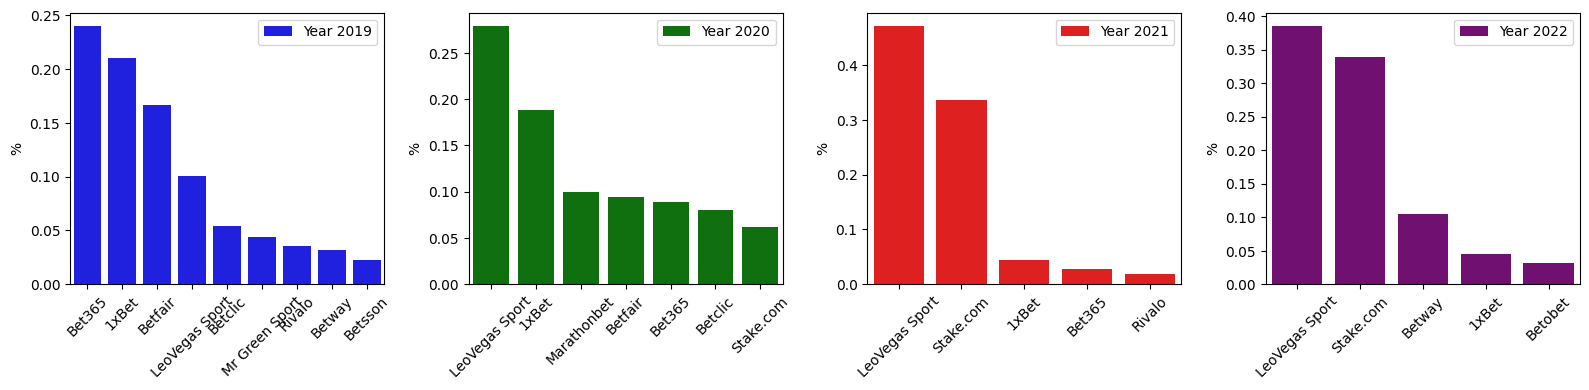

In [95]:
df = df1.copy()

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 4))

# Flatten the array of axes for easier iteration
axes = axes.flatten()

# Loop through the categories and corresponding axes
for ax, category, color in zip(axes, categories, colors):
    # Subset to the category
    subset = df[df['year'] == category]
    
    # Plot the density histogram for each category
    sns.barplot(x="Sportsbook", y="percentage", data=subset, label=f'Year {category}', ax=ax, color=color)
    
    # Set titles and labels
    ax.set_xlabel('')
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=45)
    # Adjust x ticks more sparsely
    ax.legend()  # Show the legend


# Adjust layout to prevent overlap and make all subplots square
fig.tight_layout()
# Show the plot
plt.show()


In [96]:
df_eda.iloc[[12, 17]]

,GameId,Sportsbook,Market,Scenario,Bet,Odd,public_prob,Home,Away,Datetime,BetMap,real_prob,bet_flag,n_favorable_bets,odd_dist,score,expected_return,solution,year,year_month
12,5255614,LeoVegas Sport,spread,+1/-1,away,6.25,0.160000,Internacional,Atlético Mineiro,2021-06-16,"[0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, ...",0.3682,True,410,0.6,0.48410,2.301250,0.000154,2021,2021-06
17,5252327,Bet365,spread,-3/+3,away,1.06,0.943396,Santos,Ceará,2021-06-06,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.9491,True,447,0.0,0.47455,1.006046,0.049842,2021,2021-06


In [97]:
df_test = df_eda[df_eda.Datetime.apply(str) == '2022-08-21']
df_test.sort_values('solution', ascending=False)
df_test.groupby('Datetime')['solution'].agg(lambda x: (x**2).sum()).reset_index(name='hhi')

,Datetime,hhi
0,2022-08-21,0.169097


In [98]:
df_test = df_eda[df_eda.Datetime.apply(str) == '2022-08-21']
df_test.sort_values('solution', ascending=False)

,GameId,Sportsbook,Market,Scenario,Bet,Odd,public_prob,Home,Away,Datetime,BetMap,real_prob,bet_flag,n_favorable_bets,odd_dist,score,expected_return,solution,year,year_month
6027,5925045,LeoVegas Sport,spread,-2/+2,away,1.170,0.854701,Atlético-GO,Cuiabá,2022-08-21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, ...",0.8762,True,492,0.0,0.43810,1.025154,0.283277,2022,2022-08
5996,5925025,LeoVegas Sport,spread,-2/+2,away,1.270,0.787402,Athletico-PR,América-MG,2022-08-21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, ...",0.8326,True,484,0.1,0.46630,1.057402,0.223892,2022,2022-08
5999,5925040,LeoVegas Sport,over/under,0.5,over,1.080,0.925926,Red Bull Bragantino,Ceará,2022-08-21,"[0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.9483,True,516,0.0,0.47415,1.024164,0.115830,2022,2022-08
6006,5925041,1xBet,spread,-3/+3,away,1.060,0.943396,Palmeiras,Flamengo,2022-08-21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.9437,True,514,0.0,0.47185,1.000322,0.114703,2022,2022-08
6025,5925045,LeoVegas Sport,over/under,0.5,over,1.100,0.909091,Atlético-GO,Cuiabá,2022-08-21,"[0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.9351,True,492,0.0,0.46755,1.028610,0.094804,2022,2022-08
6019,5925044,Stake.com,over/under,1.5,over,1.490,0.671141,Fortaleza,Corinthians,2022-08-21,"[0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, ...",0.7953,True,499,0.2,0.49765,1.184997,0.038551,2022,2022-08
5997,5925025,Megapari Sport,spread,-3/+3,away,1.085,0.921659,Athletico-PR,América-MG,2022-08-21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.9303,True,484,0.0,0.46515,1.009375,0.021301,2022,2022-08
6000,5925040,Megapari Sport,spread,-3/+3,away,1.085,0.921659,Red Bull Bragantino,Ceará,2022-08-21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.9392,True,516,0.0,0.46960,1.019032,0.019849,2022,2022-08
6022,5925044,LeoVegas Sport,over/under,0.5,over,1.100,0.909091,Fortaleza,Corinthians,2022-08-21,"[0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.9405,True,499,0.0,0.47025,1.034550,0.016169,2022,2022-08
6018,5925043,LeoVegas Sport,over/under,4.5,over,10.500,0.095238,Juventude,Botafogo,2022-08-21,"[0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, ...",0.1123,True,71,0.2,0.15615,1.179150,0.015912,2022,2022-08


In [99]:
(0.379232*1.11 + 0.002102*1.5 + 0.023948*2.55)

0.4851679200000001

In [100]:
odds_dt = df_test.copy()
for game_id, game_data in odds_dt.groupby('GameId', sort=False):
    scenario = gameid_to_outcome[game_id]
    financial_return = get_bet_return(df=game_data,
                                        allocation_array=game_data.solution,
                                        scenario=scenario)

    print(f"game_id: {game_id}; financial_return: {np.round(financial_return, 3)}; scenario: {scenario}")

    # track_record.append([str(game_id),
    #                         financial_return,
    #                         len(game_data),
    #                         odds_dt.n_favorable_bets.values[0],
    #                         time_limit_flag,
    #                         is_valid_solution,
    #                         iteration_date])

game_id: 5925025; financial_return: 0.317; scenario: 1 : 1
game_id: 5925040; financial_return: 0.15; scenario: 1 : 1
game_id: 5925041; financial_return: 0.122; scenario: 1 : 1
game_id: 5925042; financial_return: 0.0; scenario: 1 : 0
game_id: 5925043; financial_return: 0.015; scenario: 2 : 2
game_id: 5925044; financial_return: 0.028; scenario: 1 : 0
game_id: 5925045; financial_return: 0.44; scenario: 1 : 1


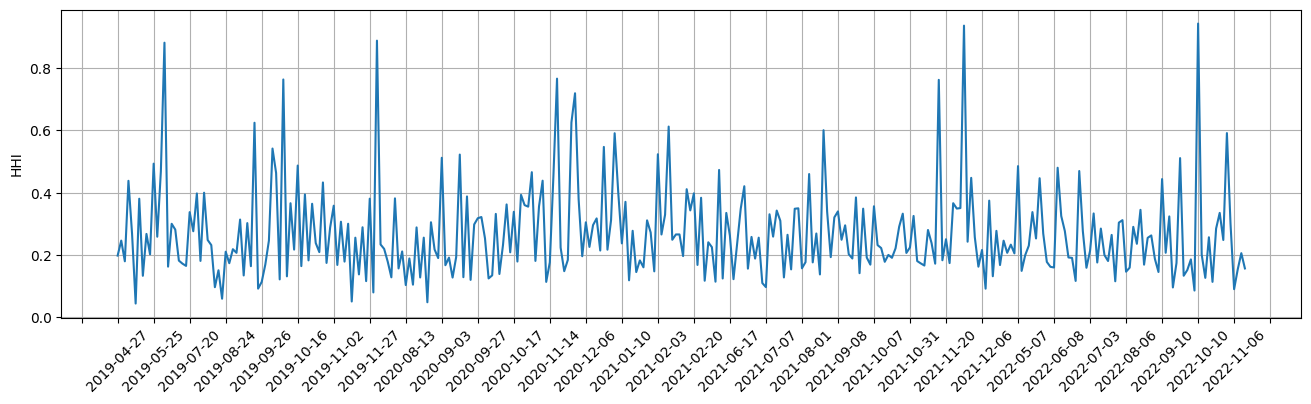

In [101]:
df_plot = df_eda.groupby('Datetime')['solution'].agg(lambda x: (x**2).sum()).reset_index(name='hhi')

plt.figure(figsize=(16, 4))

# Assuming you have a DataFrame named df_plot with columns 'year_month' and 'n_sportsbooks'
sns.lineplot(data=df_plot, x='Datetime', y='hhi')
plt.xlabel('')
plt.ylabel('HHI')

# Adjust x ticks more sparsely
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(40))
plt.grid(True)
plt.show()

In [102]:
from dependencies.utils import get_scenarios
df_eda.iloc[[12, 17]].BetMap.apply(get_scenarios).values

array([list(['0 : 2', '0 : 3', '0 : 4', '0 : 5', '0 : 6', '1 : 3', '1 : 4', '1 : 5', '1 : 6', '2 : 4', '2 : 5', '2 : 6', '3 : 5', '3 : 6', '4 : 6']),
       list(['0 : 0', '0 : 1', '0 : 2', '0 : 3', '0 : 4', '0 : 5', '0 : 6', '1 : 0', '1 : 1', '1 : 2', '1 : 3', '1 : 4', '1 : 5', '1 : 6', '2 : 0', '2 : 1', '2 : 2', '2 : 3', '2 : 4', '2 : 5', '2 : 6', '3 : 1', '3 : 2', '3 : 3', '3 : 4', '3 : 5', '3 : 6', '4 : 2', '4 : 3', '4 : 4', '4 : 5', '4 : 6', '5 : 3', '5 : 4', '5 : 5', '5 : 6', '6 : 4', '6 : 5', '6 : 6'])],
      dtype=object)

In [103]:
odds_dt.BetMap.apply(get_scenarios).values

array([list(['0 : 1', '0 : 2', '0 : 3', '0 : 4', '0 : 5', '0 : 6', '1 : 0', '1 : 1', '1 : 2', '1 : 3', '1 : 4', '1 : 5', '1 : 6', '2 : 0', '2 : 1', '2 : 2', '2 : 3', '2 : 4', '2 : 5', '2 : 6', '3 : 0', '3 : 1', '3 : 2', '3 : 3', '3 : 4', '3 : 5', '3 : 6', '4 : 0', '4 : 1', '4 : 2', '4 : 3', '4 : 4', '4 : 5', '4 : 6', '5 : 0', '5 : 1', '5 : 2', '5 : 3', '5 : 4', '5 : 5', '5 : 6', '6 : 0', '6 : 1', '6 : 2', '6 : 3', '6 : 4', '6 : 5', '6 : 6']),
       list(['0 : 2', '0 : 3', '0 : 4', '0 : 5', '0 : 6', '1 : 1', '1 : 2', '1 : 3', '1 : 4', '1 : 5', '1 : 6', '2 : 0', '2 : 1', '2 : 2', '2 : 3', '2 : 4', '2 : 5', '2 : 6', '3 : 0', '3 : 1', '3 : 2', '3 : 3', '3 : 4', '3 : 5', '3 : 6', '4 : 0', '4 : 1', '4 : 2', '4 : 3', '4 : 4', '4 : 5', '4 : 6', '5 : 0', '5 : 1', '5 : 2', '5 : 3', '5 : 4', '5 : 5', '5 : 6', '6 : 0', '6 : 1', '6 : 2', '6 : 3', '6 : 4', '6 : 5', '6 : 6']),
       list(['0 : 0', '0 : 1', '0 : 2', '0 : 3', '0 : 4', '0 : 5', '0 : 6', '1 : 0', '1 : 1', '1 : 2', '1 : 3', '1 : 4', '1 

<Figure size 2400x2400 with 0 Axes>

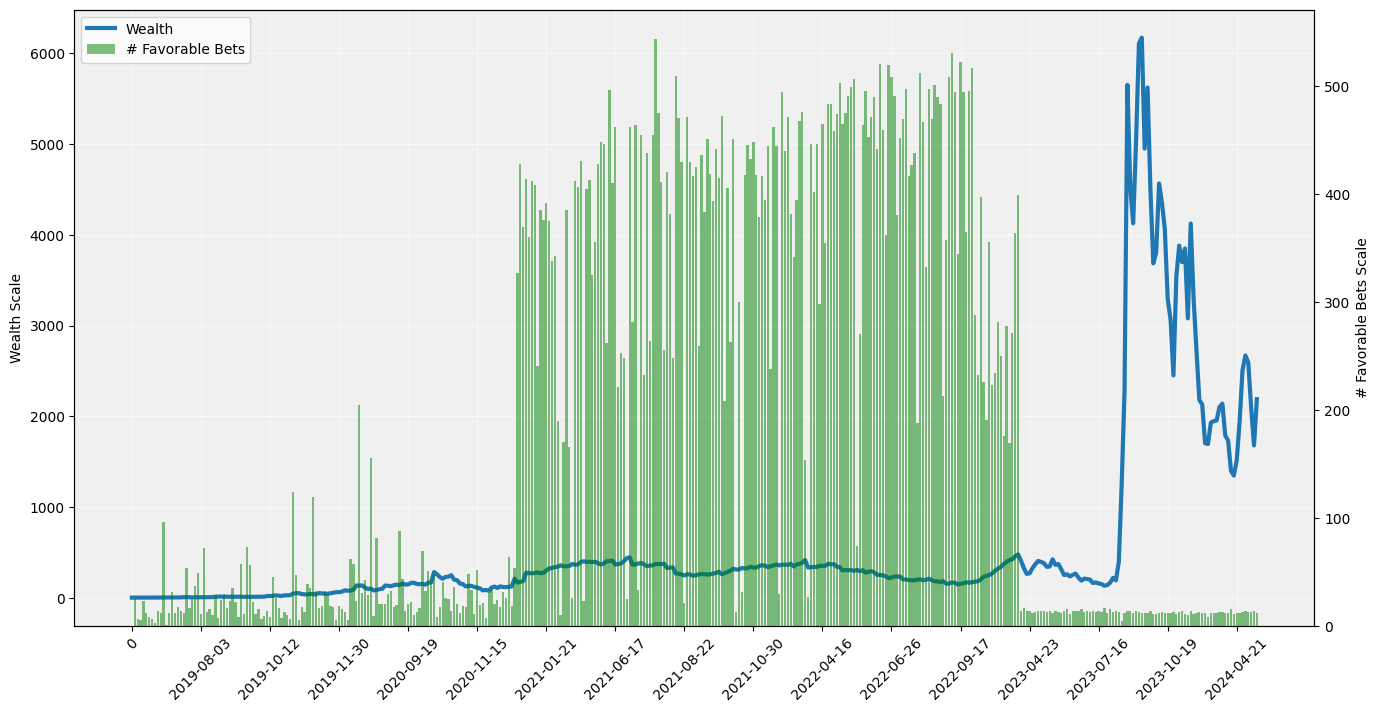

In [3]:
df = pd.read_csv("artefacts/20240613233738/result_plot.csv")


import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming 'df' is your DataFrame and 'date' contains date strings
# Example DataFrame creation if not provided
# df = pd.DataFrame({
#     'date': ['2021-01-01', '2021-01-02', '2021-01-03', ...],
#     'stake': [10, 15, 20, ...],
#     'n_favorable_bets': [2, 3, 5, ...]
# })

plt.figure(figsize=(24, 24))

# Create a figure and a primary axis
fig, ax1 = plt.subplots(figsize=(16, 8))

# Set the axes background color
ax1.set_facecolor('#f0f0f0')

# First line plot on the primary y-axis
line1, = ax1.plot(df.date, df.stake, label='Wealth', linewidth=3)
ax1.set_ylabel('Wealth Scale')
ax1.tick_params(axis='y')

# Manually setting x-ticks
# Assuming you want to set ticks at every nth point for clarity, with n determined by your data size
n = max(1, len(df) // 16)  # Adjust n as necessary based on your data size
selected_ticks = df['date'][::n]  # Select every nth date for ticks
ax1.set_xticks(selected_ticks)
ax1.set_xticklabels(selected_ticks, rotation=45)  # Rotate labels to prevent overlap

# Setting a simple white grid aligned with the primary y-axis
ax1.grid(True, color='white', linestyle='-', linewidth=0.5, alpha=0.7)  # White grid lines

# Create a secondary y-axis for the second line plot
ax2 = ax1.twinx()
bars = ax2.bar(df.date, df.n_favorable_bets, color='g', label='# Favorable Bets', width=.8, alpha=0.5)  # White bars with some transparency
ax2.set_ylabel('# Favorable Bets Scale')
ax2.tick_params(axis='y')

# Add legends and title
#plt.title('Dual Y-Axis Line Plots with String Dates')
lines = [line1, bars]
labels = [l.get_label() for l in lines]
plt.legend(lines, labels, loc='upper left')

# Show the plot
plt.show()

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

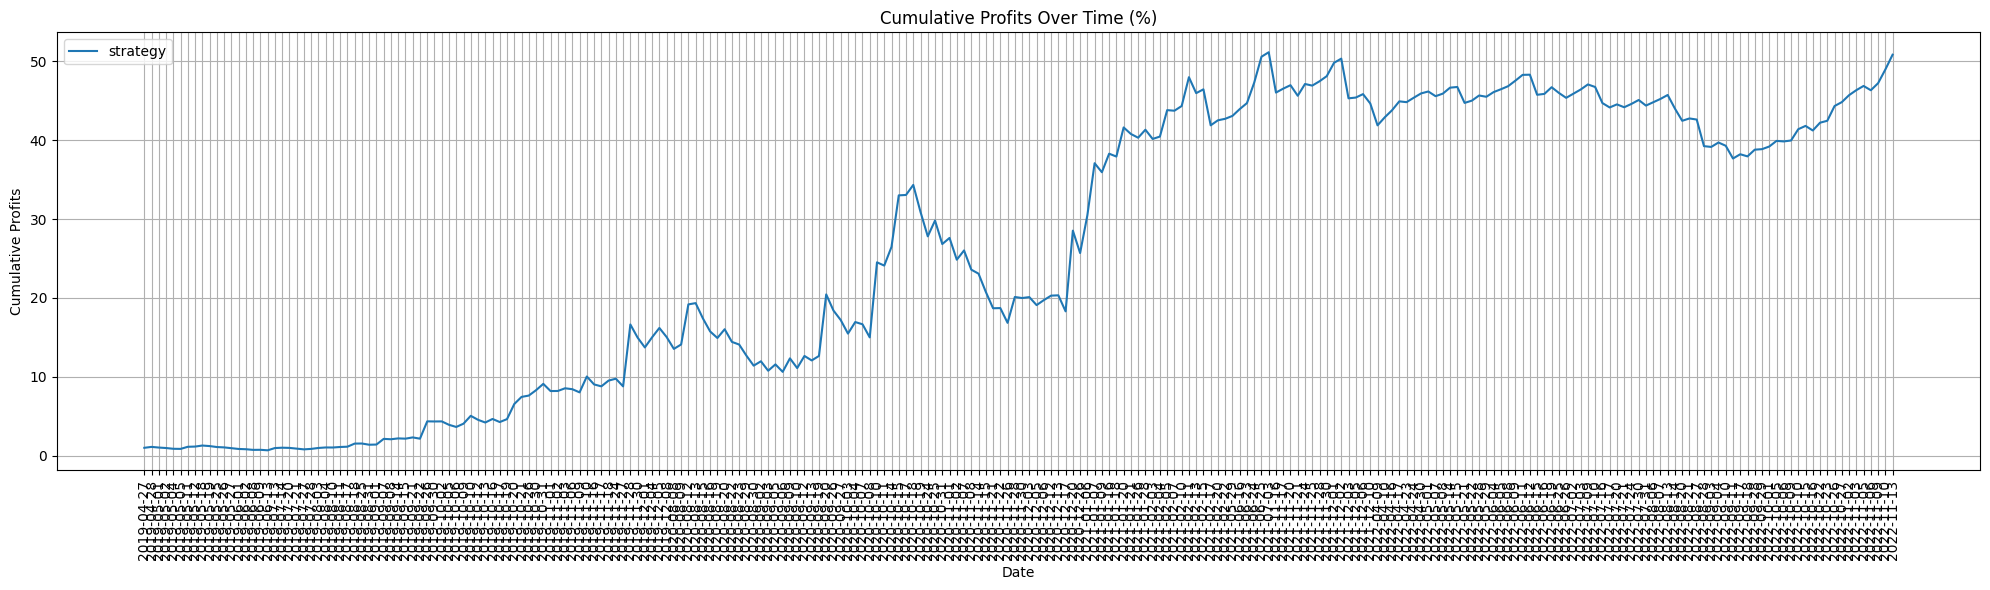

In [5]:
df_strategy = pd.read_csv("artefacts/20240607104721/result_plot.csv").iloc[1:]
#df_strategy.date = pd.to_datetime(df_strategy.date)

plt.figure(figsize=(20, 6))
plt.plot(df_strategy.date, df_strategy.stake, label='strategy')

# current_directory = os.getcwd()
# artefacts_path = f"{current_directory}/artefacts"
# for file in os.listdir(artefacts_path):
#     if 'baselineTrue' in file:
#         df_baseline = pd.read_csv(f"{artefacts_path}/{file}/result_plot.csv")
#         df_baseline['date'] = df_baseline.date.apply(lambda x: x[:10])
#         df_baseline = df_baseline.groupby('date', sort=False).last().reset_index().iloc[1:]
#         #df_baseline.date = pd.to_datetime(df_baseline.date)
#         plt.plot(df_baseline.date, df_baseline.stake)

#         print(file)

plt.xlabel('Date')
plt.ylabel('Cumulative Profits')
plt.xticks(rotation=90)
plt.title('Cumulative Profits Over Time (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [161]:
df_strategy

,date,return,stake,n_favorable_bets
1,2019-04-27,0.535150,0.953515,25
2,2019-04-28,1.179411,0.970622,6
3,2019-05-01,0.677122,0.939283,5
4,2019-05-02,1.547813,0.990738,23
5,2019-05-04,0.681716,0.959204,12
...,...,...,...,...
304,2022-11-03,1.443602,61.784259,278
305,2022-11-05,1.299681,63.635814,169
306,2022-11-06,1.207668,64.957330,271
307,2022-11-09,1.408239,67.609142,364


In [6]:
import pandas as pd
from artifacts import process_results, compute_stake, build_plot_df
track_record = pd.read_csv("artefacts/20240607104721/result.csv")
track_record.columns = ['GameId', 'return',	'n_bets', 'n_favorable_bets', 'time_limit_flag', 'is_valid_solution', 'Datetime']
aggregator = "Datetime"
do_baseline = False
df = process_results(aggregator, do_baseline, track_record)
stake = compute_stake(df, percentage=0.20)
#return build_plot_df(stake, do_baseline, df)

if do_baseline:
    df['Datetime'] = df.apply(lambda x: f"{x['Datetime']}_{x['GameId']}", axis=1)

plot_df = pd.DataFrame(
    {'date': ['0'] + list(df.Datetime),
    'return': [0] + list(df['return']),
    #'count': [0] + list(df['count']),
    #'n_bets': [0] + list(df.n_bets),
    'stake': stake,
    'n_favorable_bets': [0] + list(df.n_favorable_bets)}
)

In [7]:
plot_df

,date,return,stake,n_favorable_bets
0,0,0.000000,1.000000,0
1,2019-04-27,0.961065,0.992213,5
2,2019-04-28,2.144909,1.219412,4
3,2019-05-01,0.252521,1.037115,2
4,2019-05-02,0.415542,0.915885,5
...,...,...,...,...
238,2022-11-05,1.115217,168.830748,4
239,2022-11-06,0.884055,164.915736,4
240,2022-11-09,1.191943,171.246618,4
241,2022-11-10,1.367170,183.821946,4


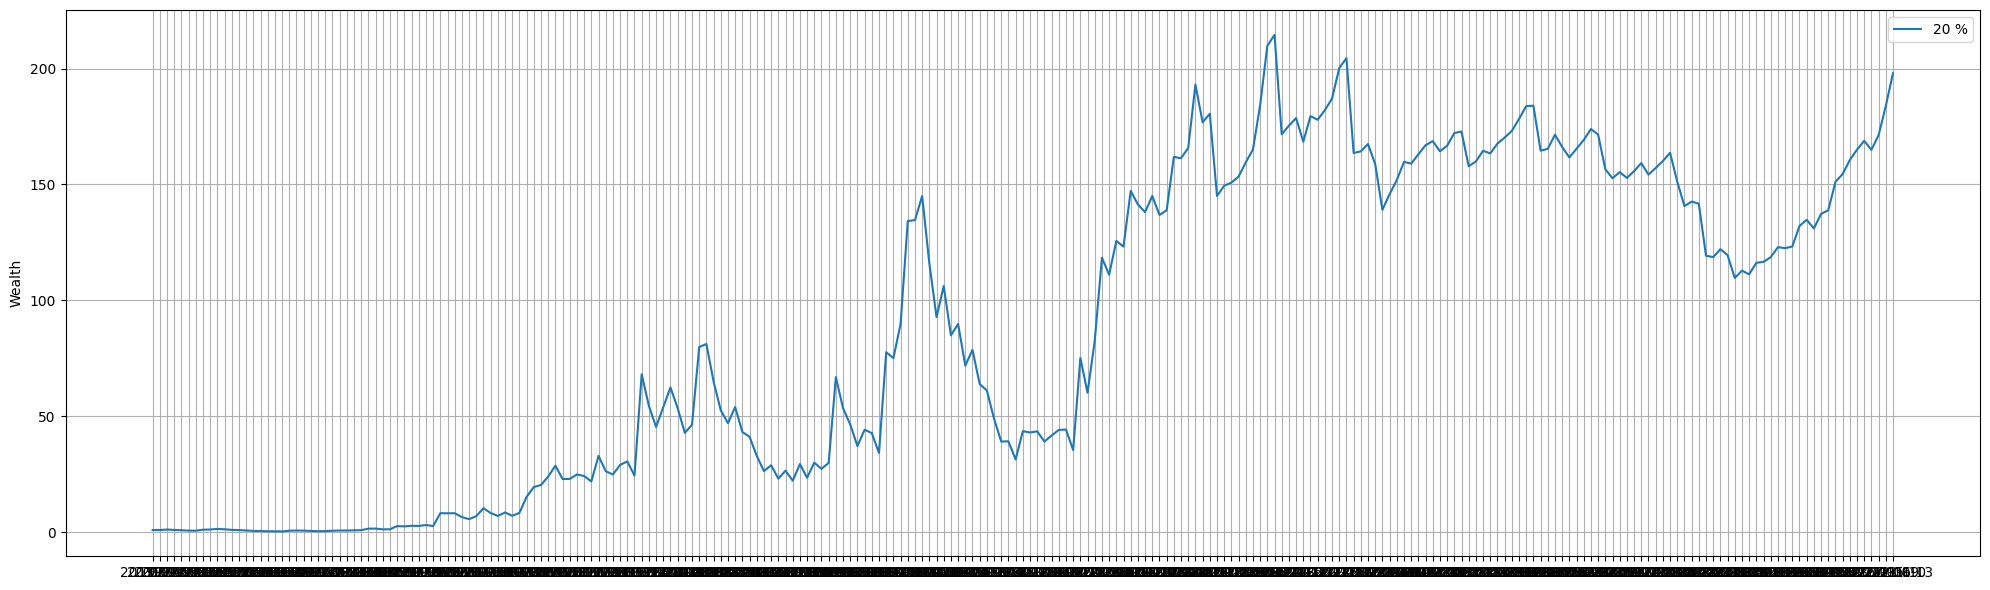

In [9]:
plt.figure(figsize=(20, 6))
#df_strategy = pd.read_csv("artefacts/20240506155232/result_plot.csv")
#plt.plot(df_strategy.date, df_strategy.stake, label='10 %')
plt.plot(plot_df.date, plot_df.stake, label='20 %')
# Manually setting x-ticks
#selected_ticks = df_strategy['date'][::len(df_strategy) // 32]  # Adjust the step size as needed
#plt.xticks(selected_ticks, rotation=45)
plt.ylabel('Wealth')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

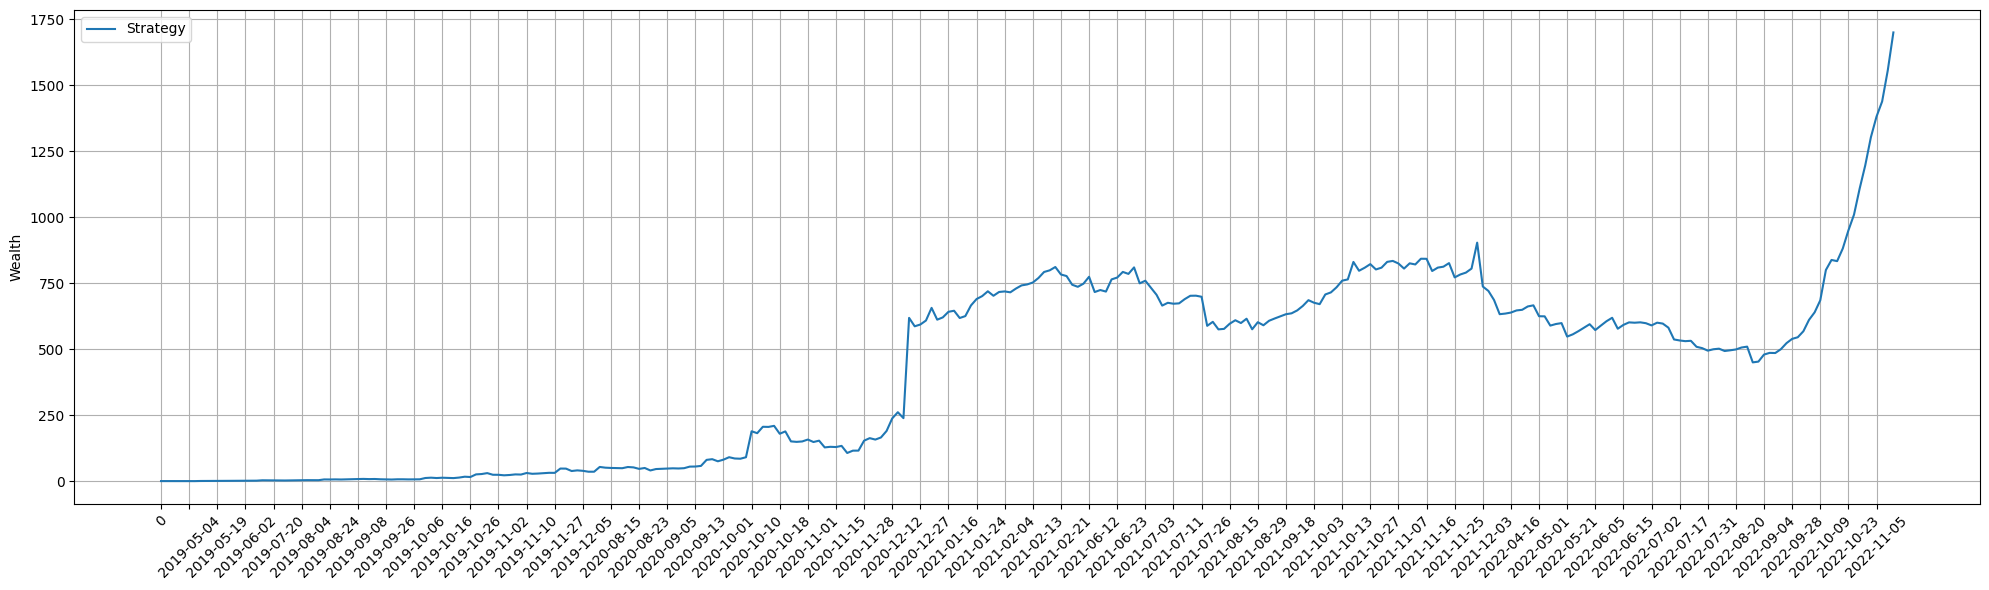

In [146]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(20, 6))
plt.plot(plot_df['date'], plot_df['stake'], label='Strategy')

# Set labels and title
plt.ylabel('Wealth')

# Improve x-ticks: Rotate and manually thin out
plt.xticks(rotation=45)  # Rotate to prevent overlap
# Optionally, you can reduce the number of x-ticks displayed
tick_spacing = 5  # Adjust this number based on your dataset's size and density
plt.xticks(ticks=plot_df['date'][::tick_spacing])  # Show every nth label to reduce clutter

plt.legend()
plt.grid(True)
plt.tight_layout()  # This adjusts subplots to give some padding and prevent overlap
plt.show()


In [131]:
current_directory = os.getcwd()
artefacts_path = f"{current_directory}/artefacts/random/"
df_baseline = pd.read_csv(f"{artefacts_path}/20240507004659/result_plot.csv")
df_baseline['date'] = df_baseline.date.apply(lambda x: x[:10])
df_baseline = df_baseline.groupby('date', sort=False).last().reset_index().iloc[1:]
df_baseline.date.nunique()

100

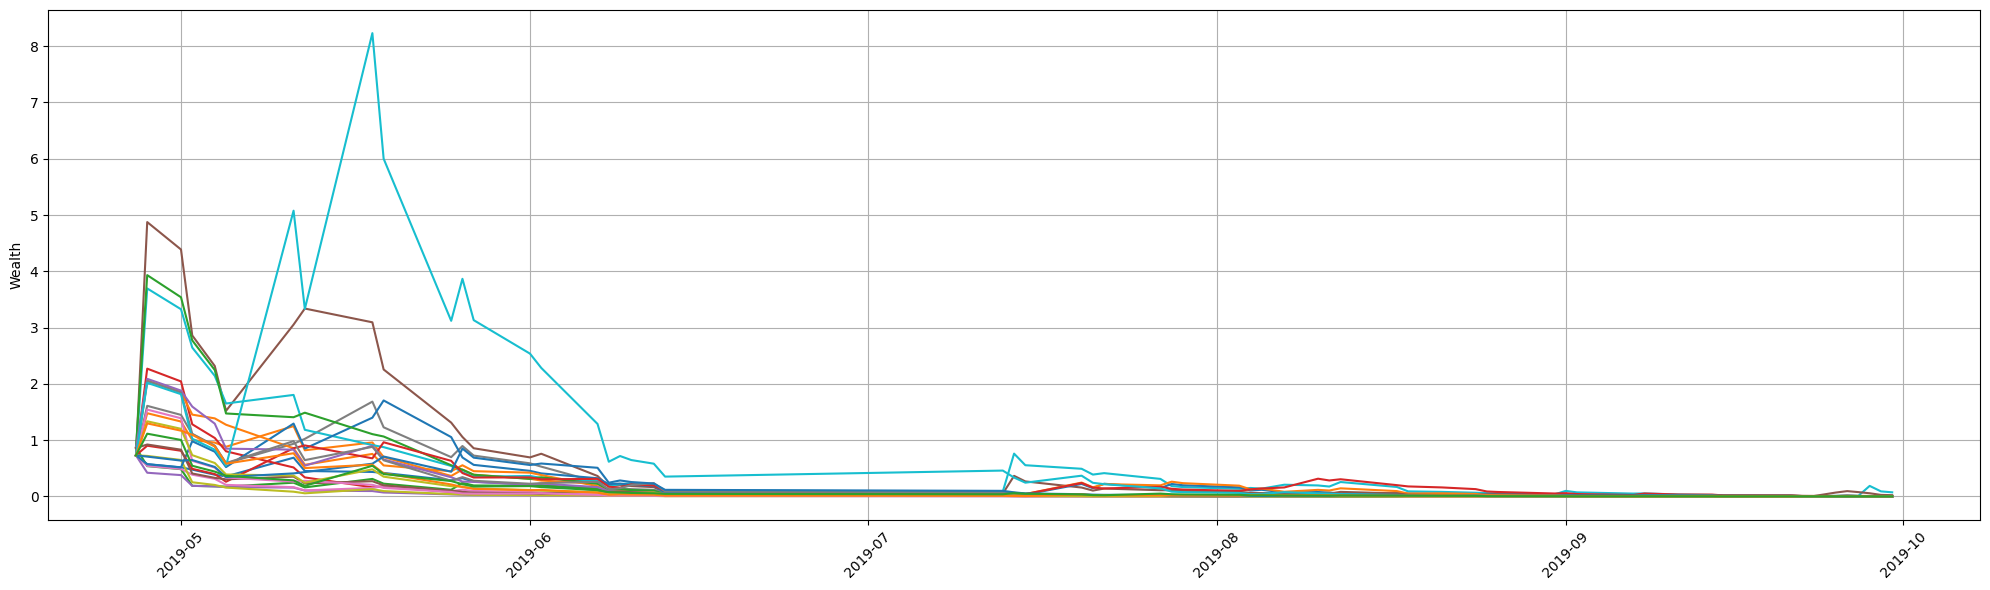

In [140]:
#df_strategy = pd.read_csv("artefacts/aggregatorDatetime_min_games1_do_baselineFalse_20231201163246/result_plot.csv").iloc[1:]
#df_strategy.date = pd.to_datetime(df_strategy.date)

plt.figure(figsize=(20, 6))
#plt.plot(df_strategy.date, df_strategy.stake, label='strategy')

current_directory = os.getcwd()
artefacts_path = f"{current_directory}/artefacts/random/"
for file in os.listdir(artefacts_path):
    #if '20240507004659' in file:
    df_baseline = pd.read_csv(f"{artefacts_path}/{file}/result_plot.csv")
    df_baseline['date'] = df_baseline.date.apply(lambda x: x[:10])
    df_baseline = df_baseline[df_baseline.date < '2019-10-01']
    df_baseline = df_baseline.sort_values('date', ascending=True)
    df_baseline = df_baseline.groupby('date', sort=False).last().reset_index().iloc[1:]
    df_baseline.date = pd.to_datetime(df_baseline.date)
    plt.plot(df_baseline.date, df_baseline.stake)

plt.yticks(np.arange(0, 9, 1))  # This sets the ticks at every integer from 1 to 10
plt.ylabel('Wealth')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()